# Modélisation ALM — Gap Actif-Passif et Immunisation

## Contexte métier
En assurance Vie, l'assureur s'engage à verser des capitaux futurs à ses assurés.
Ces engagements (le passif) sont financés par un portefeuille d'actifs obligataires.

L'ALM consiste à s'assurer que ces deux côtés du bilan réagissent de la même façon
aux variations de taux d'intérêt. Ce projet modélise ce mécanisme de façon simplifiée.

In [50]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


## Module 1 — Projection du passif

On modélise un portefeuille de 1000 contrats assurance Vie.
Chaque année, des clients sortent du portefeuille par rachat ou décès.
À l'échéance (année 10), tous les clients restants sont remboursés.

L'objectif métier : connaître exactement les flux que l'assureur
devra verser chaque année pour dimensionner son portefeuille d'actifs.

In [51]:

# ============================================================
# MODULE 1 — PROJECTION DU PASSIF ASSURANCE VIE
# ============================================================

# Paramètres du portefeuille de contrats
nb_contrats = 1000          # nombre de contrats initiaux
capital_par_contrat = 10000 # capital garanti par contrat (€)
taux_rachat = 0.03          # 3% de rachats par an
taux_mortalite = 0.01       # 1% de décès par an
horizon = 10                # durée de projection en années
taux_actualisation = 0.03   # taux d'actualisation du passif

# Projection année par année
clients = nb_contrats
flux_passif = []

for t in range(1, horizon + 1):
    deces = clients * taux_mortalite
    rachats = clients * taux_rachat
    
    if t < horizon:
        flux = (deces + rachats) * capital_par_contrat
    else:
        # à l'échéance tous les clients restants sont remboursés
        flux = clients * capital_par_contrat
    
    flux_passif.append(flux)
    clients = clients - deces - rachats

# Résultats
df_passif = pd.DataFrame({
    'Année': range(1, horizon + 1),
    'Flux_passif': flux_passif
})


pd.options.display.float_format = '{:,.0f}'.format
print("=== PROJECTION DU PASSIF ===")
print(df_passif.to_string(index=False))
print(f"\nTotal engagements : {sum(flux_passif):,.0f} €")

=== PROJECTION DU PASSIF ===
 Année  Flux_passif
     1      400,000
     2      384,000
     3      368,640
     4      353,894
     5      339,739
     6      326,149
     7      313,103
     8      300,579
     9      288,556
    10    6,925,340

Total engagements : 10,000,000 €


In [52]:
flux_passif

[400000.0,
 384000.0,
 368640.00000000006,
 353894.4,
 339738.624,
 326149.07904,
 313103.1158784,
 300578.991243264,
 288555.8315935334,
 6925339.9582448015]

In [53]:
sum(flux_passif)

10000000.0

## Module 2 — Portefeuille obligataire

L'assureur investit les primes encaissées en obligations d'État (OAT).
Pour chaque obligation on calcule :

### Prix
Le prix d'une obligation est la somme des flux futurs actualisés au taux de marché $r$ :

$$Prix = \sum_{t=1}^{n} \frac{F_t}{(1+r)^t}$$

où $F_t = C$ pour $t < n$ et $F_n = C + N$ avec $C$ le coupon annuel et $N$ le nominal.

### Duration de Macaulay
Moyenne pondérée des dates de paiement, où le poids de chaque flux
est sa valeur actualisée rapportée au prix total :

$$D_{Mac} = \sum_{t=1}^{n} t \times \frac{F_t / (1+r)^t}{Prix}$$

### Duration modifiée
Sensibilité du prix à une variation de taux de 1% :

$$D_{Mod} = \frac{D_{Mac}}{1+r}$$

$$\Delta Prix \approx -D_{Mod} \times \Delta r \times Prix$$

In [54]:
# ============================================================
# MODULE 2 — PORTEFEUILLE OBLIGATAIRE CÔTÉ ACTIF
# ============================================================

# Portefeuille de 5 obligations
obligations = pd.DataFrame({
    'Nom':     ['OAT 2ans', 'OAT 4ans', 'OAT 6ans', 'OAT 8ans', 'OAT 10ans'],
    'Nominal': [1_000_000, 1_500_000, 2_000_000, 2_500_000, 3_000_000],
    'Coupon':  [0.015,     0.020,     0.025,     0.030,     0.035],
    'Maturite':[2,         4,         6,         8,         10]
})


taux_marche = 0.03  # taux de marché actuel

def prix_obligation(nominal, coupon, maturite, taux):
    """Calcule le prix d'une obligation par actualisation des flux"""
    flux = [nominal * coupon] * maturite
    flux[-1] += nominal  # remboursement du nominal à l'échéance
    prix = sum(f / (1 + taux)**t for t, f in enumerate(flux, 1))
    return prix

def duration_macaulay(nominal, coupon, maturite, taux):
    flux = [nominal * coupon] * maturite
    flux[-1] += nominal
    prix = prix_obligation(nominal, coupon, maturite, taux)
    dur = sum(t * (f / (1 + taux)**t) / prix 
              for t, f in enumerate(flux, 1))
    return round(dur, 2)

def duration_modifiee(nominal, coupon, maturite, taux):
    return round(duration_macaulay(nominal, coupon, maturite, taux) / (1 + taux), 2)

# Calcul pour chaque obligation
obligations['Prix'] = obligations.apply(
    lambda r: prix_obligation(r['Nominal'], r['Coupon'], r['Maturite'], taux_marche), axis=1)

obligations['Duration_Macaulay'] = obligations.apply(
    lambda r: duration_macaulay(r['Nominal'], r['Coupon'], r['Maturite'], taux_marche), axis=1)

obligations['Duration_Modifiee'] = obligations.apply(
    lambda r: duration_modifiee(r['Nominal'], r['Coupon'], r['Maturite'], taux_marche), axis=1)

# Duration du portefeuille = moyenne pondérée par la valeur de marché
valeur_totale_actif = obligations['Prix'].sum()
duration_portefeuille = (obligations['Duration_Macaulay'] * obligations['Prix']).sum() / valeur_totale_actif
duration_modifiee_portefeuille = duration_portefeuille / (1 + taux_marche)

obligations = obligations.round({'Duration_Macaulay': 2, 'Duration_Modifiee': 2, 'Prix': 0})

print("\n=== PORTEFEUILLE OBLIGATAIRE ===")
print(obligations[['Nom', 'Nominal', 'Prix', 'Duration_Macaulay', 'Duration_Modifiee']].to_string(
    index=False, 
    formatters={
        'Prix': '{:,.0f}'.format,
        'Duration_Macaulay': '{:.2f}'.format,
        'Duration_Modifiee': '{:.2f}'.format
    }
))


=== PORTEFEUILLE OBLIGATAIRE ===
      Nom  Nominal      Prix Duration_Macaulay Duration_Modifiee
 OAT 2ans  1000000   971,298              1.99              1.93
 OAT 4ans  1500000 1,444,244              3.88              3.77
 OAT 6ans  2000000 1,945,828              5.64              5.48
 OAT 8ans  2500000 2,500,000              7.23              7.02
OAT 10ans  3000000 3,127,953              8.64              8.39


In [55]:
obligations['Prix']

0     971,298
1   1,444,244
2   1,945,828
3   2,500,000
4   3,127,953
Name: Prix, dtype: float64

In [56]:
print(f"\nValeur totale du portefeuille : {valeur_totale_actif:,.0f} €")
print(f"Duration Macaulay du portefeuille : {duration_portefeuille:.2f} ans")
print(f"Duration Modifiée du portefeuille : {duration_modifiee_portefeuille:.2f} ans")


Valeur totale du portefeuille : 9,989,323 €
Duration Macaulay du portefeuille : 6.37 ans
Duration Modifiée du portefeuille : 6.18 ans


## Module 3 — Duration du passif

Les flux du passif projetés au module 1 se comportent comme les flux d'une obligation.
On leur applique exactement le même calcul de duration.

### Valeur actuelle du passif

$$V_{passif} = \sum_{t=1}^{n} \frac{FL_t}{(1+r)^t}$$

Où $FL_t$ est le flux versé aux assurés à l'année $t$.

### Duration de Macaulay du passif

$$D_{passif} = \sum_{t=1}^{n} t \times \frac{FL_t / (1+r)^t}{V_{passif}}$$

### Duration modifiée du passif

$$D_{mod,passif} = \frac{D_{passif}}{1+r}$$

**Interprétation métier :** Un passif concentré en fin de période
(comme ici avec le gros flux en année 10) aura une duration longue.
L'actif doit donc lui aussi avoir une duration longue pour couvrir ces engagements.

In [57]:
# ============================================================
# MODULE 3 — DURATION DU PASSIF
# ============================================================

# Calcul de la valeur actuelle du passif
valeur_passif = sum(f / (1 + taux_actualisation)**t 
                    for t, f in enumerate(flux_passif, 1))

# Duration de Macaulay du passif
duration_passif = sum(t * (f / (1 + taux_actualisation)**t) / valeur_passif 
                      for t, f in enumerate(flux_passif, 1))

# Duration modifiée du passif
duration_modifiee_passif = duration_passif / (1 + taux_actualisation)

print("\n=== DURATION DU PASSIF ===")
print(f"Valeur actuelle du passif    : {valeur_passif:,.0f} €")
print(f"Duration Macaulay du passif  : {duration_passif:.2f} ans")
print(f"Duration Modifiée du passif  : {duration_modifiee_passif:.2f} ans")




=== DURATION DU PASSIF ===
Valeur actuelle du passif    : 7,834,420 €
Duration Macaulay du passif  : 8.13 ans
Duration Modifiée du passif  : 7.89 ans


## Module 4 — Gap actif-passif

Le gap de duration mesure l'écart de sensibilité aux taux entre actif et passif :

$$Gap = D_{passif} - D_{actif}$$

**Si $Gap > 0$** : le passif est plus sensible que l'actif.
Quand les taux baissent, le passif augmente plus vite que l'actif → perte économique.

**Si $Gap = 0$** : immunisation parfaite.
Les deux côtés du bilan réagissent de la même façon aux variations de taux.

La perte économique estimée pour un choc $\Delta r$ est :

$$\Delta Surplus \approx -(D_{mod,passif} \times V_{passif} - D_{mod,actif} \times V_{actif}) \times \Delta r$$

In [58]:
# ============================================================
# MODULE 4 — GAP ACTIF-PASSIF
# ============================================================

gap_duration = duration_passif - duration_portefeuille

print("\n=== GAP ACTIF-PASSIF ===")
print(f"Duration Macaulay actif      : {duration_portefeuille:.2f} ans")
print(f"Duration Macaulay passif     : {duration_passif:.2f} ans")
print(f"Gap de duration              : {gap_duration:.2f} ans")

if gap_duration > 0:
    print(f"\nInterprétation : le passif est plus long que l'actif.")
    print(f"Si les taux baissent, le passif augmente plus vite que l'actif → risque pour l'assureur.")
else:
    print(f"\nInterprétation : l'actif est plus long que le passif.")
    print(f"Si les taux montent, l'actif perd plus de valeur que le passif → risque pour l'assureur.")


=== GAP ACTIF-PASSIF ===
Duration Macaulay actif      : 6.37 ans
Duration Macaulay passif     : 8.13 ans
Gap de duration              : 1.76 ans

Interprétation : le passif est plus long que l'actif.
Si les taux baissent, le passif augmente plus vite que l'actif → risque pour l'assureur.


## Module 5 — Stress tests et immunisation

### Stress tests

On simule l'impact de 5 scénarios de taux sur le surplus $S = V_{actif} - V_{passif}$ :

$$S(\Delta r) = V_{actif}(\Delta r) - V_{passif}(\Delta r)$$

Les scénarios -200bp et +200bp sont directement inspirés des stress tests Solvabilité II.



In [59]:
# ============================================================
# MODULE 5 — CHOCS DE TAUX ET IMMUNISATION
# ============================================================

def valeur_actif_choc(obligations, taux_choc):
    """Recalcule la valeur du portefeuille après un choc de taux"""
    return sum(
        prix_obligation(r['Nominal'], r['Coupon'], r['Maturite'], taux_marche + taux_choc)
        for _, r in obligations.iterrows()
    )

def valeur_passif_choc(flux_passif, taux_choc):
    """Recalcule la valeur actuelle du passif après un choc de taux"""
    return sum(f / (1 + taux_actualisation + taux_choc)**t 
               for t, f in enumerate(flux_passif, 1))

# Scénarios de chocs
chocs = [-0.02, -0.01, 0, +0.01, +0.02]
labels = ['-200bp', '-100bp', 'Base', '+100bp', '+200bp']

resultats = []
for choc, label in zip(chocs, labels):
    val_actif = valeur_actif_choc(obligations, choc)
    val_passif = valeur_passif_choc(flux_passif, choc)
    surplus = val_actif - val_passif
    resultats.append({
        'Scénario': label,
        'Valeur Actif': val_actif,
        'Valeur Passif': val_passif,
        'Surplus': surplus
    })

df_chocs = pd.DataFrame(resultats)

print("\n=== CHOCS DE TAUX ===")
print(df_chocs.to_string(
    index=False,
    formatters={
        'Valeur Actif': '{:,.0f}'.format,
        'Valeur passif': '{:,.0f}'.format,
        'Surplus': '{:,.0f}'.format
    }
))




=== CHOCS DE TAUX ===
Scénario Valeur Actif  Valeur Passif   Surplus
  -200bp   11,335,177      9,203,729 2,131,449
  -100bp   10,633,660      8,484,648 2,149,012
    Base    9,989,323      7,834,420 2,154,903
  +100bp    9,396,705      7,245,686 2,151,019
  +200bp    8,850,930      6,711,942 2,138,988




Avant immunisation, le surplus reste stable autour de **2.15M€** quel que soit
le scénario de taux — l'écart entre le meilleur (-200bp : 2.13M€) et le pire
(+200bp : 2.14M€) est faible.

Cela peut sembler rassurant, mais c'est trompeur : le gap de duration de 1.76 ans
expose l'assureur à un risque croissant si les taux bougent fortement.
C'est précisément ce que l'immunisation vient corriger.

### Immunisation par duration-matching

L'objectif est de trouver une réallocation du portefeuille telle que $D_{actif} = D_{passif}$.

On résout le système suivant avec deux obligations (courte et longue) :

$$w \times D_{court} + (1-w) \times D_{long} = D_{passif}$$

$$\Rightarrow w = \frac{D_{passif} - D_{long}}{D_{court} - D_{long}}$$

Où $w$ est le poids alloué à l'obligation courte.

**Limite :** En pratique on utilise un optimiseur sur le portefeuille complet
avec des contraintes de diversification et de budget.

In [60]:
# ============================================================
# IMMUNISATION — duration matching exact
# ============================================================

# On garde seulement OAT 2ans et OAT 10ans
# On cherche le poids w tel que :
# w * duration_2ans + (1-w) * duration_10ans = duration_passif

dur_2ans = duration_macaulay(1_000_000, 0.015, 2, taux_marche)
dur_10ans = duration_macaulay(1_000_000, 0.035, 10, taux_marche)
valeur_totale = valeur_totale_actif

# Résolution : w * dur_2ans + (1-w) * dur_10ans = duration_passif
# w = (duration_passif - dur_10ans) / (dur_2ans - dur_10ans)
w = (duration_passif - dur_10ans) / (dur_2ans - dur_10ans)

montant_2ans = w * valeur_totale
montant_10ans = (1 - w) * valeur_totale

print(f"\n=== STRATEGIE D'IMMUNISATION ===")
print(f"Poids OAT 2ans  : {w*100:.1f}% → {montant_2ans:,.0f} €")
print(f"Poids OAT 10ans : {(1-w)*100:.1f}% → {montant_10ans:,.0f} €")

# Nouveau portefeuille immunisé
obligations_immu = pd.DataFrame({
    'Nom':     ['OAT 2ans', 'OAT 10ans'],
    'Nominal': [montant_2ans, montant_10ans],
    'Coupon':  [0.015, 0.035],
    'Maturite':[2, 10]
})

obligations_immu['Prix'] = obligations_immu.apply(
    lambda r: prix_obligation(r['Nominal'], r['Coupon'], r['Maturite'], taux_marche), axis=1)
obligations_immu['Duration_Macaulay'] = obligations_immu.apply(
    lambda r: duration_macaulay(r['Nominal'], r['Coupon'], r['Maturite'], taux_marche), axis=1)

valeur_totale_immu = obligations_immu['Prix'].sum()
duration_immu = (obligations_immu['Duration_Macaulay'] * obligations_immu['Prix']).sum() / valeur_totale_immu
gap_apres = duration_passif - duration_immu

print(f"\nDuration actif avant  : {duration_portefeuille:.2f} ans")
print(f"Duration actif après  : {duration_immu:.2f} ans")
print(f"Duration passif       : {duration_passif:.2f} ans")
print(f"Gap avant             : {gap_duration:.2f} ans")
print(f"Gap après             : {gap_apres:.2f} ans")

# Chocs après immunisation
resultats_immu = []
for choc, label in zip(chocs, labels):
    val_actif = valeur_actif_choc(obligations_immu, choc)
    val_passif = valeur_passif_choc(flux_passif, choc)
    surplus = val_actif - val_passif
    resultats_immu.append({
        'Scénario': label,
        'Valeur Actif': val_actif,
        'Valeur Passif': val_passif,
        'Surplus': surplus
    })

df_chocs_immu = pd.DataFrame(resultats_immu)

print("\n=== CHOCS DE TAUX APRES IMMUNISATION ===")
print(df_chocs_immu.to_string(
    index=False,
    formatters={
        'Valeur Actif': '{:,.0f}'.format,
        'Valeur Passif': '{:,.0f}'.format,
        'Surplus': '{:,.0f}'.format
    }
))


=== STRATEGIE D'IMMUNISATION ===
Poids OAT 2ans  : 7.7% → 767,224 €
Poids OAT 10ans : 92.3% → 9,222,099 €

Duration actif avant  : 6.37 ans
Duration actif après  : 8.16 ans
Duration passif       : 8.13 ans
Gap avant             : 1.76 ans
Gap après             : -0.03 ans

=== CHOCS DE TAUX APRES IMMUNISATION ===
Scénario Valeur Actif Valeur Passif   Surplus
  -200bp   12,180,514     9,203,729 2,976,785
  -100bp   11,224,449     8,484,648 2,739,801
    Base   10,360,634     7,834,420 2,526,214
  +100bp    9,579,149     7,245,686 2,333,463
  +200bp    8,871,233     6,711,942 2,159,291


## Résultats de l'immunisation

La stratégie de duration-matching réalloue le portefeuille à 92.3% sur des obligations
longues (OAT 10ans) et 7.7% sur des obligations courtes (OAT 2ans).
Le gap passe de **1.76 ans à -0.03 ans** — quasi nul.

Sous stress de taux, le surplus reste positif dans tous les scénarios,
ce qui confirme la solvabilité de l'assureur. On observe cependant que le surplus
diminue quand les taux montent (+200bp : 2.16M€ vs 2.53M€ en base) — effet attendu
de la convexité résiduelle entre actif et passif.

## Module 6 — Tableau de bord

Le dashboard résume visuellement les résultats clés de l'analyse ALM :

- **Flux du passif** : concentration des engagements en année 10,
  ce qui justifie le besoin d'une duration longue côté actif.

- **Duration actif vs passif** : visualisation du gap avant et après
  immunisation — de 1.76 ans à -0.03 ans.

- **Surplus sous stress** : impact des chocs de taux sur le bilan
  avant et après immunisation.

- **Composition du portefeuille** : réallocation après duration-matching,
  concentrée à 92.8% sur des obligations longues (OAT 10ans).

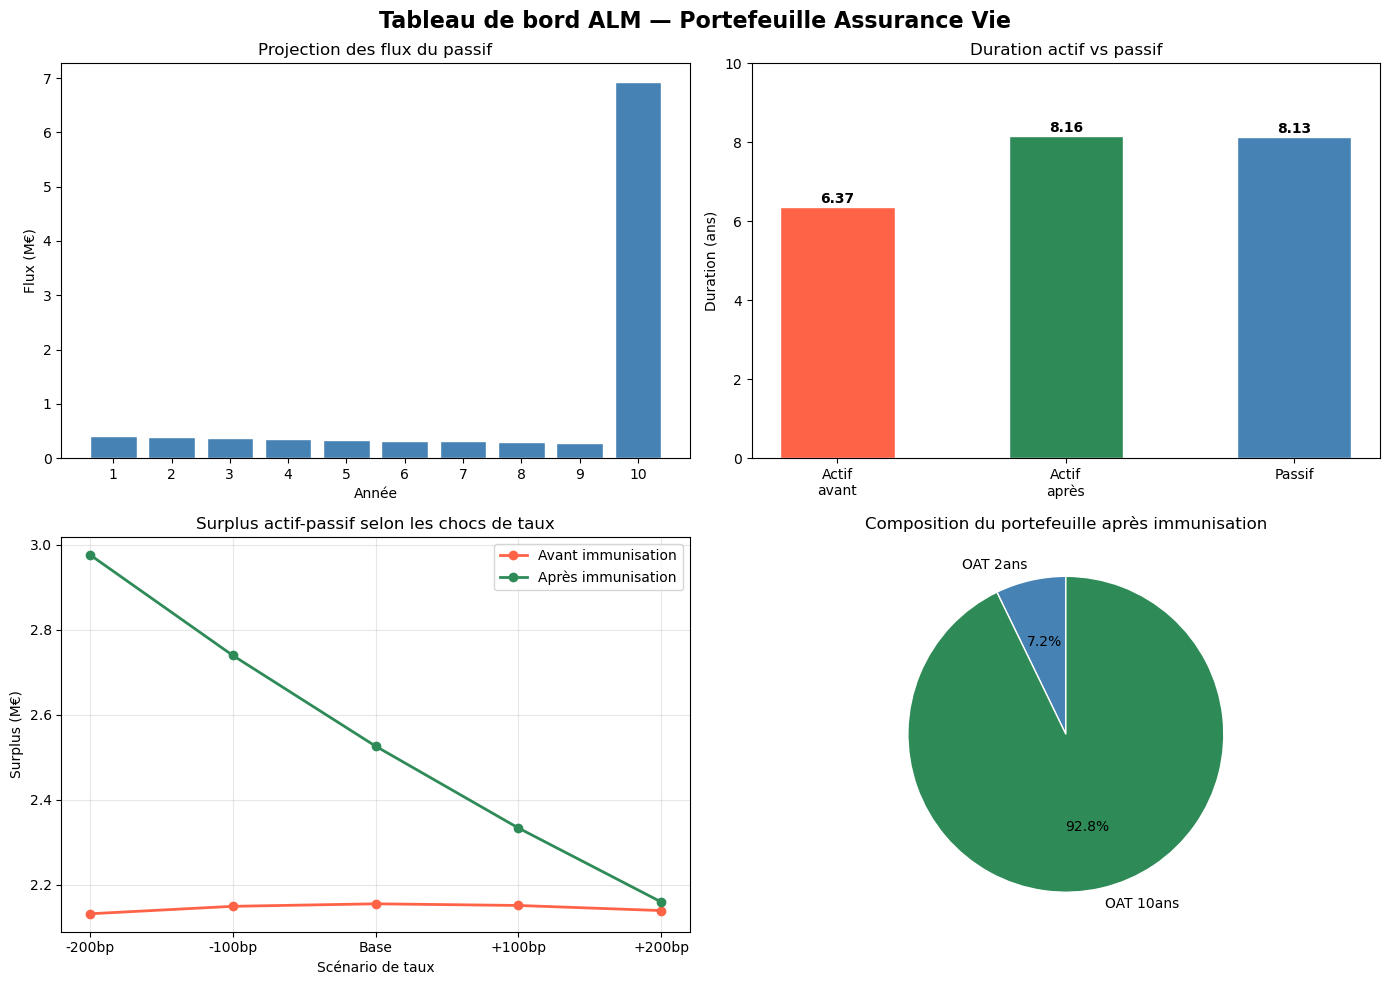


Dashboard sauvegardé : alm_dashboard.png


In [61]:
# ============================================================
# MODULE 6 — VISUALISATION
# ============================================================

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Tableau de bord ALM — Portefeuille Assurance Vie', 
             fontsize=16, fontweight='bold')

# ── Graphique 1 : Flux du passif ──────────────────────────
axes[0, 0].bar(df_passif['Année'], df_passif['Flux_passif'] / 1_000_000, 
               color='steelblue', edgecolor='white')
axes[0, 0].set_title('Projection des flux du passif')
axes[0, 0].set_xlabel('Année')
axes[0, 0].set_ylabel('Flux (M€)')
axes[0, 0].set_xticks(range(1, 11))

# ── Graphique 2 : Duration actif vs passif ────────────────
categories = ['Actif\navant', 'Actif\naprès', 'Passif']
durations = [duration_portefeuille, duration_immu, duration_passif]
colors = ['tomato', 'seagreen', 'steelblue']
bars = axes[0, 1].bar(categories, durations, color=colors, edgecolor='white', width=0.5)
axes[0, 1].set_title('Duration actif vs passif')
axes[0, 1].set_ylabel('Duration (ans)')
axes[0, 1].set_ylim(0, 10)
for bar, val in zip(bars, durations):
    axes[0, 1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
                    f'{val:.2f}', ha='center', fontweight='bold')

# ── Graphique 3 : Surplus avant/après chocs ───────────────
scenarios = [r['Scénario'] for r in resultats]
surplus_avant = [r['Surplus'] / 1_000_000 for r in resultats]
surplus_apres = [r['Surplus'] / 1_000_000 for r in resultats_immu]

x = range(len(scenarios))
axes[1, 0].plot(scenarios, surplus_avant, 'o-', color='tomato', 
                linewidth=2, label='Avant immunisation')
axes[1, 0].plot(scenarios, surplus_apres, 'o-', color='seagreen', 
                linewidth=2, label='Après immunisation')
axes[1, 0].set_title('Surplus actif-passif selon les chocs de taux')
axes[1, 0].set_xlabel('Scénario de taux')
axes[1, 0].set_ylabel('Surplus (M€)')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# ── Graphique 4 : Composition du portefeuille ─────────────
noms = obligations_immu['Nom'].tolist()
valeurs = obligations_immu['Prix'].tolist()
axes[1, 1].pie(valeurs, labels=noms, autopct='%1.1f%%',
               colors=['steelblue', 'seagreen'],
               startangle=90, wedgeprops={'edgecolor': 'white'})
axes[1, 1].set_title('Composition du portefeuille après immunisation')

plt.tight_layout()
plt.savefig('alm_dashboard.png', dpi=150, bbox_inches='tight')
plt.show()
print("\nDashboard sauvegardé : alm_dashboard.png")

In [63]:
pip install --upgrade nbconvert

Note: you may need to restart the kernel to use updated packages.


In [64]:
import subprocess
subprocess.run(['pip', 'install', 'nbconvert==6.5.4'], check=True)

CompletedProcess(args=['pip', 'install', 'nbconvert==6.5.4'], returncode=0)